# 09 sensitivity, thirty minute threshold

Repeats the solve with a thirty minute one way threshold, the value applied by
MacLachlan et al. (2024), and compares the selections.

Only the reachability matrices change. The demand surface, the candidate set and
the model are identical, so any difference is attributable to the threshold.

Requires `reach_cand_30.npz` and `reach_supp_30.npz`, produced by rerunning 07
with `THRESHOLD = THRESHOLD_SENSITIVITY` and the output paths changed.

In [15]:
import sys
from pathlib import Path

# config.py sits beside the notebooks, so the working directory is enough. If a
# notebook is run from elsewhere, walk up until it is found.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
sys.path.insert(0, str(ROOT))
from config import *


## 1. Inputs

In [9]:
import time
from collections import defaultdict

import numpy as np
import pandas as pd
import pulp
from scipy import sparse

REACH_CAND_30 = OUT / "reach_cand_30.npz"
REACH_SUPP_30 = OUT / "reach_supp_30.npz"
for f in (REACH_CAND_30, REACH_SUPP_30):
    print(f"{'ok ' if f.exists() else 'MISSING':8s}{f}")

ok      /Users/zoey/CASA/10dissertation/28Uganda/dissertation/data_derived/reach_cand_30.npz
ok      /Users/zoey/CASA/10dissertation/28Uganda/dissertation/data_derived/reach_supp_30.npz


## 2. How much larger the problem becomes

Doubling the threshold roughly quadruples the area each point reaches, so the
solve is materially heavier.

In [10]:
demand = pd.read_csv(DEMAND_CELLS)
cand = pd.read_csv(KIKUUBE_CAND)
supp = pd.read_csv(KIKUUBE_SUPPLY)
pop = demand["pop"].values
w_u5 = demand["share_under5"].values
nD, nC, nS = len(demand), len(cand), len(supp)

capC = pd.to_numeric(cand.usage_capacity, errors="coerce")
capC = capC.fillna(capC.median()).values
capS = pd.to_numeric(supp.usage_capacity, errors="coerce")
capS = capS.fillna(capS.median()).values


def coverage(path_c, path_s):
    Ac = sparse.load_npz(path_c).tocoo()
    As = sparse.load_npz(path_s).tocoo()
    cc, cs = defaultdict(list), defaultdict(list)
    for j, i in zip(Ac.row, Ac.col):
        cc[i].append(j)
    for j, i in zip(As.row, As.col):
        cs[i].append(j)
    return cc, cs, Ac.nnz + As.nnz


cov15 = coverage(REACH_CAND, REACH_SUPP)
cov30 = coverage(REACH_CAND_30, REACH_SUPP_30)
print(f"allocation variables at 15 minutes {cov15[2]:,}")
print(f"allocation variables at 30 minutes {cov30[2]:,}")
print(f"factor {cov30[2] / cov15[2]:.1f}")

allocation variables at 15 minutes 385,517
allocation variables at 30 minutes 1,495,186
factor 3.9


## 3. The same model

In [11]:
def solve(K, weight, cov_c, cov_s, time_limit=3600):
    p = pulp.LpProblem("CMCLP", pulp.LpMaximize)
    y = {j: pulp.LpVariable(f"y{j}", cat="Binary") for j in range(nC)}
    zc, zs = {}, {}
    for i in range(nD):
        for j in cov_c[i]:
            zc[(i, j)] = pulp.LpVariable(f"c{i}_{j}", lowBound=0)
        for j in cov_s[i]:
            zs[(i, j)] = pulp.LpVariable(f"s{i}_{j}", lowBound=0)

    p += (pulp.lpSum(weight[i] * zc[(i, j)] for (i, j) in zc)
          + pulp.lpSum(weight[i] * zs[(i, j)] for (i, j) in zs))

    for i in range(nD):
        terms = [zc[(i, j)] for j in cov_c[i]] + [zs[(i, j)] for j in cov_s[i]]
        if terms:
            p += pulp.lpSum(terms) <= pop[i]

    bc, bs = defaultdict(list), defaultdict(list)
    for (i, j), v in zc.items():
        bc[j].append(v)
    for (i, j), v in zs.items():
        bs[j].append(v)
    for j in range(nC):
        if bc[j]:
            p += pulp.lpSum(bc[j]) <= capC[j] * y[j]
    for j in range(nS):
        if bs[j]:
            p += pulp.lpSum(bs[j]) <= capS[j]

    p += pulp.lpSum(y.values()) <= K
    p.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=time_limit))

    chosen = sorted(j for j in range(nC) if y[j].value() and y[j].value() > 0.5)
    served = (sum(v.value() for v in zc.values())
              + sum(v.value() for v in zs.values()))
    return pulp.LpStatus[p.status], chosen, served

## 4. Solve at both thresholds

In [12]:
rows = []
for label, (cc, cs, _) in [("15 min", cov15), ("30 min", cov30)]:
    _, _, base = solve(0, np.ones(nD), cc, cs)
    print(f"{label} baseline served {base:,.0f} "
          f"({base / pop.sum():.1%} of rural demand)")
    for K in K_LIST:
        for name, w in [("efficiency", np.ones(nD)), ("equity", w_u5)]:
            t0 = time.time()
            st, chosen, served = solve(K, w, cc, cs)
            rows.append(dict(threshold=label, k=K, objective=name, status=st,
                             baseline=base, served=served, gain=served - base,
                             seconds=round(time.time() - t0), chosen=chosen))
            print(f"  k={K:3d} {name:10s} {st:8s} +{served - base:8,.0f} "
                  f"[{time.time() - t0:.0f}s]")
            pd.DataFrame(rows).to_csv(OUT / "09_threshold_sensitivity.csv",
                                      index=False)

15 min baseline served 171,138 (71.3% of rural demand)
  k=  5 efficiency Optimal  +   1,500 [69s]
  k=  5 equity     Optimal  +   1,500 [115s]
  k= 10 efficiency Optimal  +   3,000 [74s]
  k= 10 equity     Optimal  +   3,000 [96s]
  k= 20 efficiency Optimal  +   5,889 [127s]
  k= 20 equity     Optimal  +   5,889 [125s]
30 min baseline served 202,898 (84.5% of rural demand)
  k=  5 efficiency Optimal  +   1,500 [190s]
  k=  5 equity     Optimal  +   1,500 [182s]
  k= 10 efficiency Optimal  +   3,000 [209s]
  k= 10 equity     Optimal  +   3,000 [853s]
  k= 20 efficiency Optimal  +   6,000 [305s]
  k= 20 equity     Optimal  +   6,000 [228s]


## 5. Compare

In [13]:
res = pd.DataFrame(rows)
print(res[["threshold", "k", "objective", "baseline", "served", "gain"]]
      .to_string(index=False, formatters={
          "baseline": "{:,.0f}".format, "served": "{:,.0f}".format,
          "gain": "{:,.0f}".format}))

print("\nhow far the selection changes with the threshold")
for K in K_LIST:
    for name in ("efficiency", "equity"):
        a = set(res[(res.threshold == "15 min") & (res.k == K)
                    & (res.objective == name)].chosen.iloc[0])
        b = set(res[(res.threshold == "30 min") & (res.k == K)
                    & (res.objective == name)].chosen.iloc[0])
        print(f"  k={K:3d} {name:10s} {len(a & b)} of {K} points shared")

threshold  k  objective baseline  served  gain
   15 min  5 efficiency  171,138 172,638 1,500
   15 min  5     equity  171,138 172,638 1,500
   15 min 10 efficiency  171,138 174,138 3,000
   15 min 10     equity  171,138 174,138 3,000
   15 min 20 efficiency  171,138 177,027 5,889
   15 min 20     equity  171,138 177,027 5,889
   30 min  5 efficiency  202,898 204,398 1,500
   30 min  5     equity  202,898 204,398 1,500
   30 min 10 efficiency  202,898 205,898 3,000
   30 min 10     equity  202,898 205,898 3,000
   30 min 20 efficiency  202,898 208,898 6,000
   30 min 20     equity  202,898 208,898 6,000

how far the selection changes with the threshold
  k=  5 efficiency 2 of 5 points shared
  k=  5 equity     1 of 5 points shared
  k= 10 efficiency 5 of 10 points shared
  k= 10 equity     5 of 10 points shared
  k= 20 efficiency 9 of 20 points shared
  k= 20 equity     8 of 20 points shared


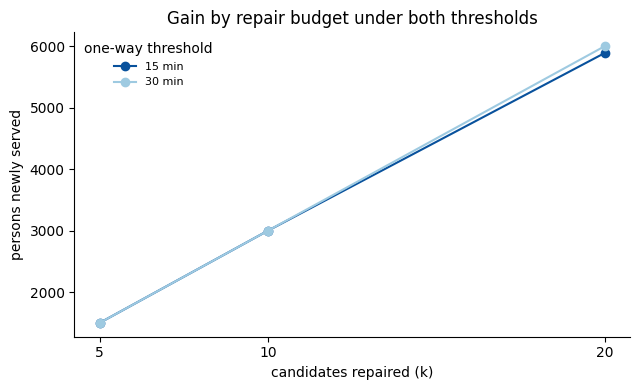

In [14]:
import matplotlib.pyplot as plt

piv = res[res.objective == "efficiency"].pivot(index="k", columns="threshold",
                                               values="gain")
fig, ax = plt.subplots(figsize=(6.5, 4))
for col, colr in zip(piv.columns, ["#08519c", "#9ecae1"]):
    ax.plot(piv.index, piv[col], marker="o", label=col, color=colr)
ax.set_xlabel("candidates repaired (k)")
ax.set_ylabel("persons newly served")
ax.set_xticks(list(piv.index))
ax.legend(frameon=False, fontsize=8, title="one-way threshold")
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Gain by repair budget under both thresholds")
plt.tight_layout()
plt.savefig(FIG / "fig_threshold_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

A selection that survives the change of threshold is more defensible than one
that does not. Report the overlap alongside the gains rather than the gains
alone.